# Free redshift and free $\sigma_\star$ on four DR2 galaxies

- Arm `zsig` from `scripts/calibration_arms_vast.py`: `poly3_total` plus two sampled nuisance parameters.
- `zred`: clipped Gaussian prior on the catalogue z, width 100 km/s, clipped at 3 sigma.
- `sigma_smooth`: clipped Gaussian prior on DR2 $\sigma_\star$, width 20 percent, clipped at 50 and 150 percent.
- Reference: the `poly3_total` fits in `results/calibration-polynomial-dr2` (same seed, same sampler settings).
- Ceridwen fork `free-z-spectrum` at 354f5e9: the Spectrum stretches its baked prediction to the sampled z.

In [1]:
import os
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.constants import c as C_LIGHT
from astropy.table import Table
from scipy.special import softmax
from scipy.stats import norm

PROJECT_ROOT = Path(os.environ.get("CERIDWEN_PROJECT_ROOT", "/Users/liuhao/Downloads/Astro project"))
RESULTS = PROJECT_ROOT / "results/redshift-sigma-wiggle"
REFERENCE = PROJECT_ROOT / "results/calibration-polynomial-dr2/poly3_total"
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
from build_dr2_quiescent_summary import formation_times  # noqa: E402
from spectral_figures import mark_absorption_features  # noqa: E402

C_KMS = float(C_LIGHT.to("km/s").value)
ARMS = ["poly3_total", "zsig"]
COLOURS = {"poly3_total": "tab:blue", "zsig": "tab:red"}
LABELS = {"logmass": r"$\log_{10}(M_\star/M_\odot)$", "t50": r"$t_{50}$ [Gyr]",
          "log_sfr": r"$\log_{10}\,\mathrm{SFR}_{0-30\,\mathrm{Myr}}\,[M_\odot\,\mathrm{yr}^{-1}]$",
          "tau_dust": r"$\tau_{\mathrm{dust}}$", "age": r"$t_{\mathrm{MW}}$ [Gyr]",
          "Z": r"$\log_{10} Z$", "afe": r"$[\alpha/\mathrm{Fe}]$"}
# CPU scan (2026-09-06): redshift offset at the minimum of the fixed-model chi2, km/s.
SCAN_DV = {"M12_185653": 0.0, "M1_206545": -21.0, "M5_172669": 52.0, "M5_173928": 0.0}
RNG = np.random.default_rng(20260906)


def _text(value):
    return value.decode() if isinstance(value, bytes) else str(value)


def load_fit(folder: Path) -> dict:
    out = {"folder": folder}
    with h5py.File(folder / "ceridwen_derived_outputs.h5", "r") as derived:
        out["attrs"] = dict(derived.attrs)
        names = [_text(v) for v in derived["summary/parameter"][:]]
        out["summary"] = pd.DataFrame(
            {"q16": derived["summary/q16"][:], "q50": derived["summary/q50"][:],
             "q84": derived["summary/q84"][:]}, index=names)
        out["diag"] = dict(derived["diagnostics"].attrs)
        out["spectrum"] = {k: derived["spectrum"][k][:] for k in derived["spectrum"]}
        out["photometry"] = {k: derived["photometry"][k][:] for k in derived["photometry"]}
        out["sfh"] = {k: derived["sfh"][k][:] for k in derived["sfh"]}
    with h5py.File(folder / "ceridwen_result.h5", "r") as result:
        out["model_attrs"] = dict(result["model"].attrs)
        out["n_calls"] = int(result["samples"].attrs["n_likelihood_calls"])
        out["wall_s"] = float(result["samples"].attrs["wall_time_s"])
        weights = softmax(np.asarray(result["samples/log_weights"][:]))
        pick = RNG.choice(len(weights), size=4000, p=weights)     # equal-weight posterior draws
        out["draws"] = {k: np.asarray(result["samples"][k][:])[pick]
                        for k in result["samples"] if not k.startswith("log_")}
    return out


def find_fits() -> dict:
    fits = {}
    for arm, root in [("poly3_total", REFERENCE), ("zsig", RESULTS / "zsig")]:
        for folder in sorted(root.iterdir()):
            if (folder / "ceridwen_derived_outputs.h5").exists():
                fits[(arm, folder.name.split("-", 1)[1])] = load_fit(folder)
    return fits


fits = find_fits()
galaxies = sorted({t for a, t in fits if a == "zsig"}, key=lambda t: fits[("zsig", t)]["attrs"]["catalogue_sn"])
legac = Table.read(PROJECT_ROOT / "data/raw/legac_dr2/legaCdr2.fits.gz").to_pandas()
legac["SPECT_ID"] = legac["SPECT_ID"].map(_text).str.strip()
legac = legac.set_index("SPECT_ID")
print(len(fits), "fits; galaxies:", galaxies)

10 fits; galaxies: ['M5_173928', 'M12_185653', 'M1_206545', 'M5_172669']


## Summary table

- One row per galaxy and arm; `dv` is the redshift offset from the catalogue in km/s.
- Raw χ² uses the observational σ, stored χ² the fitted σ_eff.
- $t_{50}$ from `formation_times`; SFR from the youngest SFH bin and the median mass.

In [2]:
def half_width(row):
    return 0.5 * (row["q84"] - row["q16"])


def derived_row(arm, target, fit):
    spec = fit["spectrum"]
    mask = spec["mask"].astype(bool)
    raw_chi2 = float(np.sum(((spec["observed"] - spec["posterior_q50"]) / spec["uncertainty"])[mask] ** 2))
    summary = fit["summary"]
    t20, t50, t80 = formation_times(fit["sfh"]["lookback_time_gyr"], fit["sfh"]["mass_fraction_draws"])
    logmass_q50 = summary.loc["logmass", "q50"]
    sfr = fit["sfh"]["normalized_sfr_draws"][:, 0] * 10 ** logmass_q50
    cat = legac.loc[target]
    row = dict(arm=arm, target=target, z=fit["attrs"]["redshift"], sn=fit["attrs"]["catalogue_sn"],
               sigma_cat=float(cat["SIGMA_STARS_PRIME"]), sigma_cat_err=float(cat["SIGMA_STARS_PRIME_err"]),
               n_pix=int(fit["diag"]["spectrum_ndof"]),
               spec_chi2_stored=float(fit["diag"]["spectrum_chi2"]), spec_chi2_raw=raw_chi2,
               phot_chi2=float(fit["diag"]["photometry_chi2"]),
               lnZ=float(fit["diag"]["log_evidence"]), lnZ_err=float(fit["diag"]["log_evidence_err"]),
               ess=float(fit["diag"]["posterior_weight_ess"]), passed=bool(fit["diag"]["passed"]),
               calls=fit["n_calls"], wall_s=fit["wall_s"])
    for name, key in [("logmass", "logmass"), ("Z", "Z"), ("afe", "afe"), ("tau_dust", "diffuse_tau_kc"),
                      ("age", "mass-weighted age [Gyr]"), ("f_calib", "calibration floor [%]"),
                      ("scaling", "spectrum_scaling")]:
        row[f"{name}_q50"] = summary.loc[key, "q50"]
        row[f"{name}_hw"] = half_width(summary.loc[key])
    for name, draws in [("t50", t50), ("log_sfr", np.log10(np.clip(sfr, 1e-30, None)))]:
        q16, q50, q84 = np.percentile(draws, [16, 50, 84])
        row[f"{name}_q50"], row[f"{name}_hw"] = q50, 0.5 * (q84 - q16)
    if "zred" in fit["draws"]:
        dv = C_KMS * (fit["draws"]["zred"] - row["z"]) / (1.0 + row["z"])
        for name, draws in [("dv", dv), ("sigma", fit["draws"]["sigma_smooth"])]:
            q16, q50, q84 = np.percentile(draws, [16, 50, 84])
            row[f"{name}_q50"], row[f"{name}_hw"] = q50, 0.5 * (q84 - q16)
        row["dv_scan"] = SCAN_DV.get(target, np.nan)
        row["sigma_pull"] = (row["sigma_q50"] - row["sigma_cat"]) / row["sigma_cat_err"]
    return row


table = pd.DataFrame([derived_row(a, t, f) for (a, t), f in fits.items()])
table = table.set_index(["target", "arm"]).sort_index()
table.to_csv(RESULTS / "zsig-vs-poly3_total.csv")
pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 60)
show = ["z", "sn", "sigma_cat", "sigma_cat_err", "dv_q50", "dv_hw", "dv_scan", "sigma_q50", "sigma_hw", "sigma_pull",
        "n_pix", "spec_chi2_raw", "spec_chi2_stored", "phot_chi2", "f_calib_q50", "scaling_q50",
        "logmass_q50", "logmass_hw", "t50_q50", "t50_hw", "age_q50", "age_hw", "tau_dust_q50", "lnZ", "calls", "wall_s"]
display(table[[c for c in show if c in table]].round(3))

z     sn  sigma_cat  sigma_cat_err  dv_q50  dv_hw  dv_scan  sigma_q50  sigma_hw  sigma_pull  n_pix  spec_chi2_raw  spec_chi2_stored  phot_chi2  f_calib_q50  scaling_q50  logmass_q50  logmass_hw  t50_q50  t50_hw  age_q50  \
target     arm                                                                                                                                                                                                                                            
M12_185653 poly3_total  0.678   21.5      173.8           10.2     NaN    NaN      NaN        NaN       NaN         NaN   3577       9844.152          3968.989     11.112        6.317        0.980       11.100       0.035    5.056   0.454    5.017   
           zsig         0.678   21.5      173.8           10.2  12.318  6.041      0.0    144.197     5.397      -2.902   3577       9777.785          3949.361     10.760        6.309        1.000       11.127       0.019    5.216   0.266    5.200   
M12_98104  poly3_total  0.981    6.6      223.5           22.3     NaN    NaN      NaN        NaN       NaN         NaN   3804       8655.031          5917.863     10.090        9.978        0.970       11.248       0.026    4.442   0.420    4.403   
M1_206545  poly3_total  0.728   31.4      210.0            8.0     NaN    NaN      NaN        NaN       NaN         NaN   3422       8661.358          4302.297     64.639        3.948        1.162       11.638       0.009    5.071   0.025    5.065   
           zsig         0.728   31.4      210.0            8.0 -19.608  4.439    -21.0    241.310     4.867       3.914   3422       8590.620          4269.540     54.131        3.916        1.144       11.633       0.010    5.068   0.019    5.064   
M4_108989  poly3_total  0.828   21.3      310.3           12.1     NaN    NaN      NaN        NaN       NaN         NaN   3735       8640.260          4263.885     12.849        4.387        0.823       11.811       0.016    4.635   0.112    4.610   
M5_172669  poly3_total  0.604  105.0      223.8            6.1     NaN    NaN      NaN        NaN       NaN         NaN   3602      29012.500          4155.579    100.101        2.662        1.305       11.329       0.011    1.768   0.068    1.846   
           zsig         0.604  105.0      223.8            6.1  18.310  3.156     52.0    231.539     3.876       1.269   3602      28946.581          4194.955    101.246        2.640        1.304       11.330       0.016    1.745   0.088    1.798   
M5_173928  poly3_total  0.959   13.3      179.7           13.3     NaN    NaN      NaN        NaN       NaN         NaN   3836      14696.941          3710.211     48.192        9.011        1.360       11.716       0.012    4.513   0.228    4.499   
           zsig         0.959   13.3      179.7           13.3   7.803  9.364      0.0    267.754     1.805       6.621   3836      14162.392          3707.122     36.364        8.719        1.316       11.711       0.010    4.510   0.056    4.500   

                        age_hw  tau_dust_q50         lnZ    calls    wall_s  
target     arm                                                               
M12_185653 poly3_total   0.370         0.172  233871.325   981500   306.476  
           zsig          0.198         0.210  233878.771  1131000  1144.049  
M12_98104  poly3_total   0.267         0.363  249681.232  1020500   307.670  
M1_206545  poly3_total   0.015         0.457  222935.229  1254500   371.469  
           zsig          0.012         0.434  222967.909  1391000  1348.911  
M4_108989  poly3_total   0.116         0.253  243350.274  1196000   354.687  
M5_172669  poly3_total   0.099         0.577  233013.763  1228500   404.483  
           zsig          0.134         0.571  233018.161  1365000  1510.908  
M5_173928  poly3_total   0.105         0.541  250191.496  1137500   354.264  
           zsig          0.039         0.471  250264.809  1410500  1410.986

## Change from poly3_total per galaxy

- Δ = `zsig` minus `poly3_total`, same seed and sampler settings.
- `dlnZ` in nats; `passed` from the stored sampler diagnostics.

In [3]:
rows = []
for target in galaxies:
    if (target, "poly3_total") not in table.index:
        continue
    ref, cur = table.loc[(target, "poly3_total")], table.loc[(target, "zsig")]
    rows.append(dict(target=target, dv_kms=cur["dv_q50"], dv_hw=cur["dv_hw"], dv_scan=cur["dv_scan"],
                     sigma_kms=cur["sigma_q50"], sigma_hw=cur["sigma_hw"], sigma_cat=cur["sigma_cat"],
                     dchi2_raw=cur["spec_chi2_raw"] - ref["spec_chi2_raw"],
                     dchi2_stored=cur["spec_chi2_stored"] - ref["spec_chi2_stored"],
                     dchi2_phot=cur["phot_chi2"] - ref["phot_chi2"], dlnZ=cur["lnZ"] - ref["lnZ"],
                     df_calib=cur["f_calib_q50"] - ref["f_calib_q50"],
                     dlogmass=cur["logmass_q50"] - ref["logmass_q50"], dt50=cur["t50_q50"] - ref["t50_q50"],
                     dage=cur["age_q50"] - ref["age_q50"], dtau=cur["tau_dust_q50"] - ref["tau_dust_q50"],
                     passed_ref=ref["passed"], passed_zsig=cur["passed"]))
delta = pd.DataFrame(rows).set_index("target")
delta.to_csv(RESULTS / "delta-vs-poly3_total.csv")
display(delta.round(3))

,dv_kms,dv_hw,dv_scan,sigma_kms,sigma_hw,sigma_cat,dchi2_raw,dchi2_stored,dchi2_phot,dlnZ,df_calib,dlogmass,dt50,dage,dtau,passed_ref,passed_zsig
target,,,,,,,,,,,,,,,,,
M5_173928,7.803,9.364,0.0,267.754,1.805,179.7,-534.549,-3.089,-11.828,73.313,-0.292,-0.006,-0.003,0.001,-0.070,True,True
M12_185653,12.318,6.041,0.0,144.197,5.397,173.8,-66.367,-19.629,-0.352,7.446,-0.008,0.027,0.160,0.183,0.038,True,True
M1_206545,-19.608,4.439,-21.0,241.310,4.867,210.0,-70.738,-32.757,-10.508,32.680,-0.032,-0.004,-0.004,-0.001,-0.024,True,True
M5_172669,18.310,3.156,52.0,231.539,3.876,223.8,-65.919,39.377,1.145,4.399,-0.022,0.000,-0.023,-0.048,-0.006,True,True


## Posteriors of the two nuisance parameters

- Left: redshift offset from the catalogue; dashed: the prior; dotted: the CPU-scan minimum.
- Right: $\sigma_\star$; grey band: DR2 value and its error; dashed: the prior.

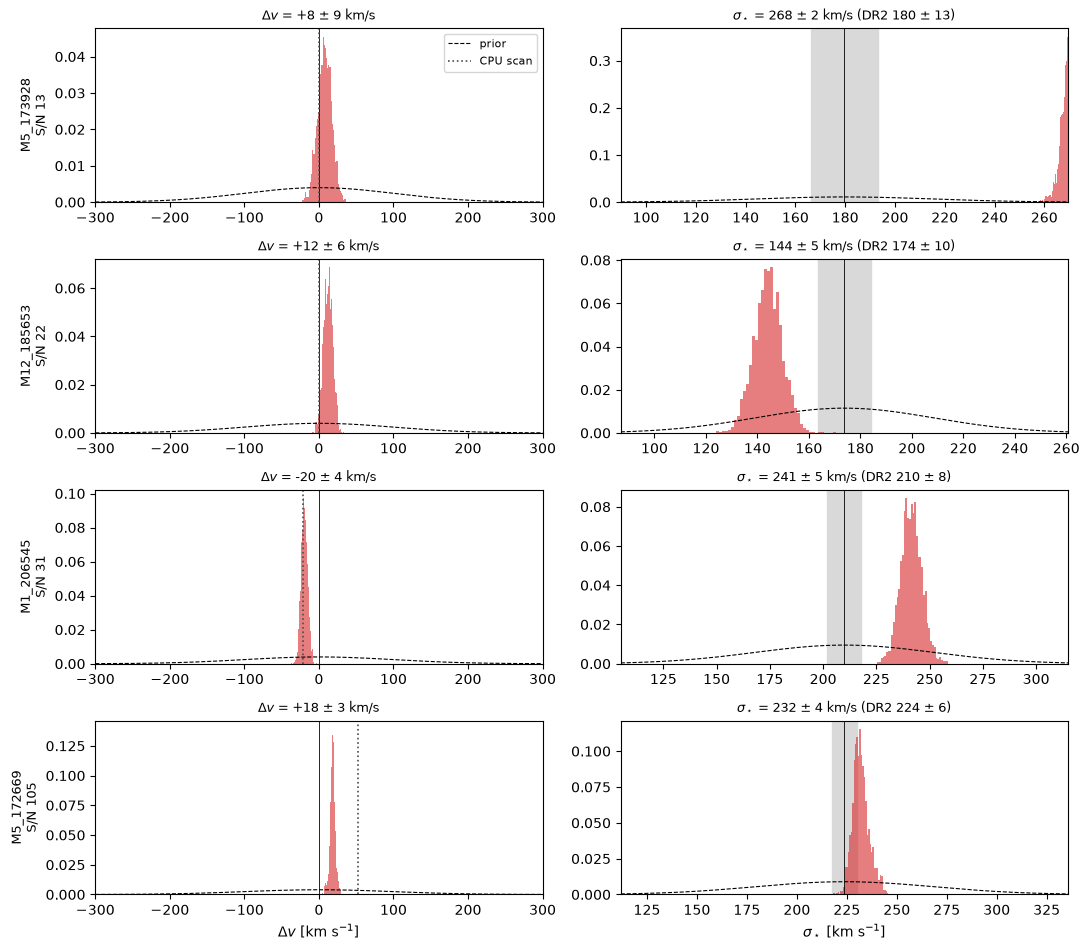

In [4]:
fig, axes = plt.subplots(len(galaxies), 2, figsize=(11, 2.4 * len(galaxies)), squeeze=False)
for row_axes, target in zip(axes, galaxies):
    fit = fits[("zsig", target)]
    row = table.loc[(target, "zsig")]
    dv = C_KMS * (fit["draws"]["zred"] - row["z"]) / (1.0 + row["z"])
    sigma = fit["draws"]["sigma_smooth"]
    ax = row_axes[0]
    ax.hist(dv, bins=40, density=True, color=COLOURS["zsig"], alpha=0.6)
    grid = np.linspace(-300, 300, 400)
    ax.plot(grid, norm.pdf(grid, 0.0, 100.0), "k--", lw=0.8, label="prior")
    ax.axvline(0.0, color="k", lw=0.6)
    ax.axvline(row["dv_scan"], color="0.3", ls=":", lw=1.2, label="CPU scan")
    ax.set_xlim(-300, 300)
    ax.set_ylabel(f"{target}\nS/N {row['sn']:.0f}", fontsize=9)
    ax.set_title(f"$\\Delta v$ = {row['dv_q50']:+.0f} $\\pm$ {row['dv_hw']:.0f} km/s", fontsize=9)
    ax = row_axes[1]
    ax.hist(sigma, bins=40, density=True, color=COLOURS["zsig"], alpha=0.6)
    lo, hi = 0.5 * row["sigma_cat"], 1.5 * row["sigma_cat"]
    grid = np.linspace(lo, hi, 400)
    ax.plot(grid, norm.pdf(grid, row["sigma_cat"], 0.2 * row["sigma_cat"]), "k--", lw=0.8, label="prior")
    ax.axvspan(row["sigma_cat"] - row["sigma_cat_err"], row["sigma_cat"] + row["sigma_cat_err"], color="0.85", zorder=0)
    ax.axvline(row["sigma_cat"], color="k", lw=0.6)
    ax.set_xlim(lo, hi)
    ax.set_title(f"$\\sigma_\\star$ = {row['sigma_q50']:.0f} $\\pm$ {row['sigma_hw']:.0f} km/s "
                 f"(DR2 {row['sigma_cat']:.0f} $\\pm$ {row['sigma_cat_err']:.0f})", fontsize=9)
axes[0, 0].legend(fontsize=8)
axes[-1, 0].set_xlabel(r"$\Delta v$ [km s$^{-1}$]")
axes[-1, 1].set_xlabel(r"$\sigma_\star$ [km s$^{-1}$]")
fig.tight_layout()
fig.savefig(RESULTS / "nuisance-posteriors.png", dpi=130)
plt.show()

## Degeneracies of the nuisance parameters

- Equal-weight draws: $\Delta v$ against $\sigma_\star$, and $\sigma_\star$ against $[\alpha/\mathrm{Fe}]$ and $t_{\mathrm{MW}}$.
- A tilted cloud means the line width trades against the physical parameter.

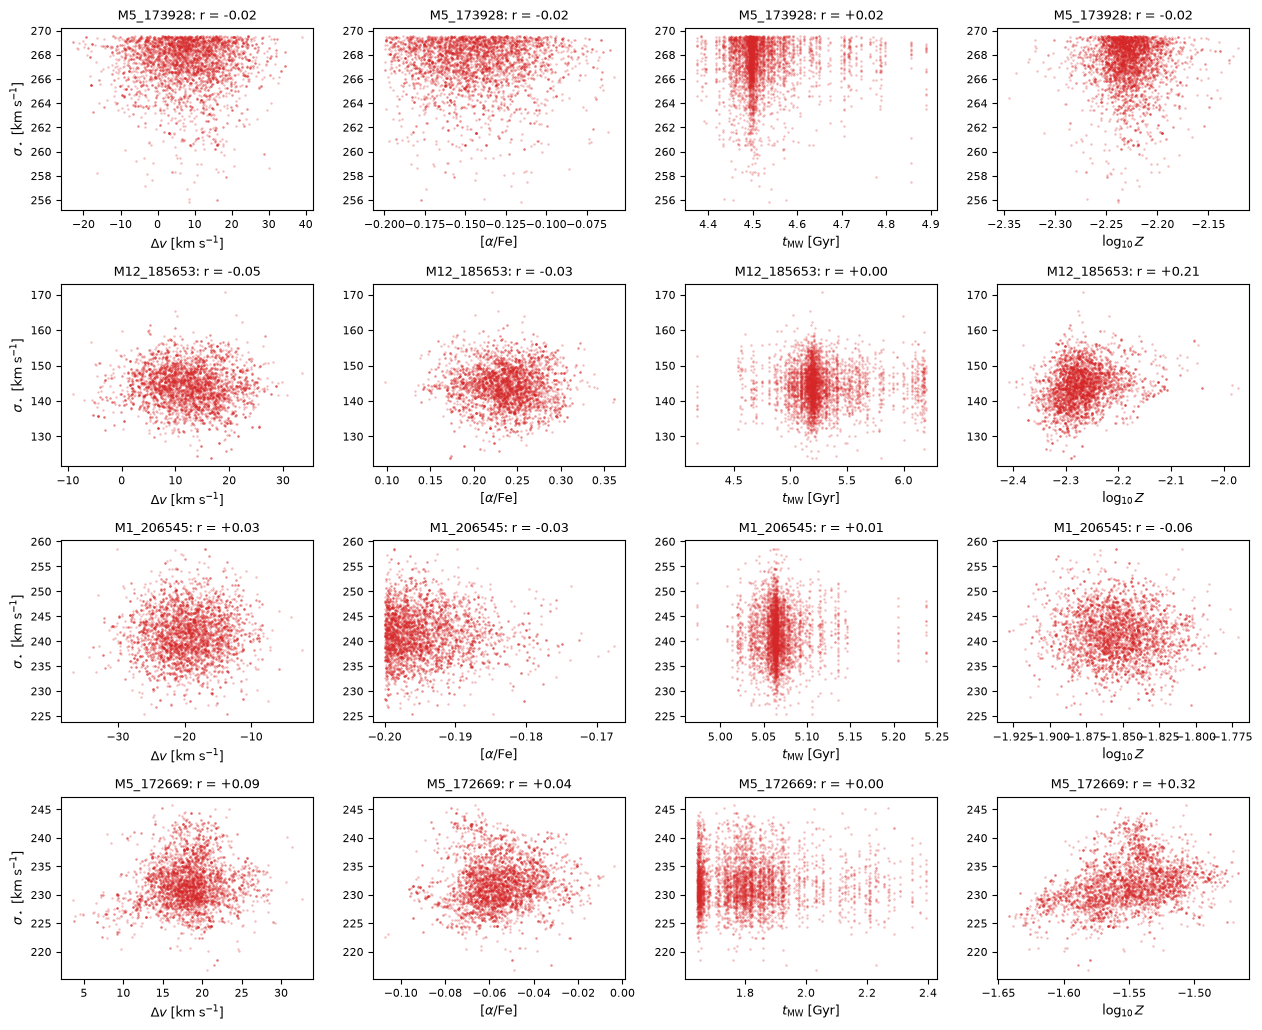

In [5]:
pairs = [("dv", r"$\Delta v$ [km s$^{-1}$]"), ("afe", LABELS["afe"]), ("age", LABELS["age"]), ("Z", LABELS["Z"])]
fig, axes = plt.subplots(len(galaxies), len(pairs), figsize=(3.2 * len(pairs), 2.6 * len(galaxies)), squeeze=False)
for row_axes, target in zip(axes, galaxies):
    fit = fits[("zsig", target)]
    row = table.loc[(target, "zsig")]
    draws = fit["draws"]
    sigma = draws["sigma_smooth"]
    columns = {"dv": C_KMS * (draws["zred"] - row["z"]) / (1.0 + row["z"]), "afe": draws["afe"], "Z": draws["Z"]}
    ages = fit["sfh"]["mass_weighted_age_gyr"]
    columns["age"] = RNG.choice(ages, size=len(sigma)) if len(ages) != len(sigma) else ages
    for ax, (key, label) in zip(row_axes, pairs):
        ax.scatter(columns[key], sigma, s=3, alpha=0.3, color=COLOURS["zsig"], lw=0)
        r = np.corrcoef(columns[key], sigma)[0, 1]
        ax.set_title(f"{target}: r = {r:+.2f}", fontsize=9)
        ax.set_xlabel(label, fontsize=9)
        ax.tick_params(labelsize=8)
    row_axes[0].set_ylabel(r"$\sigma_\star$ [km s$^{-1}$]", fontsize=9)
fig.tight_layout()
fig.savefig(RESULTS / "nuisance-degeneracies.png", dpi=130)
plt.show()

## Spectral pulls, fixed against free

- Top: pull = (observed − q50) / σ_eff, fitted pixels only.
- Bottom: cumulative stored χ² along the spectrum.
- Grey band: masked pixels.

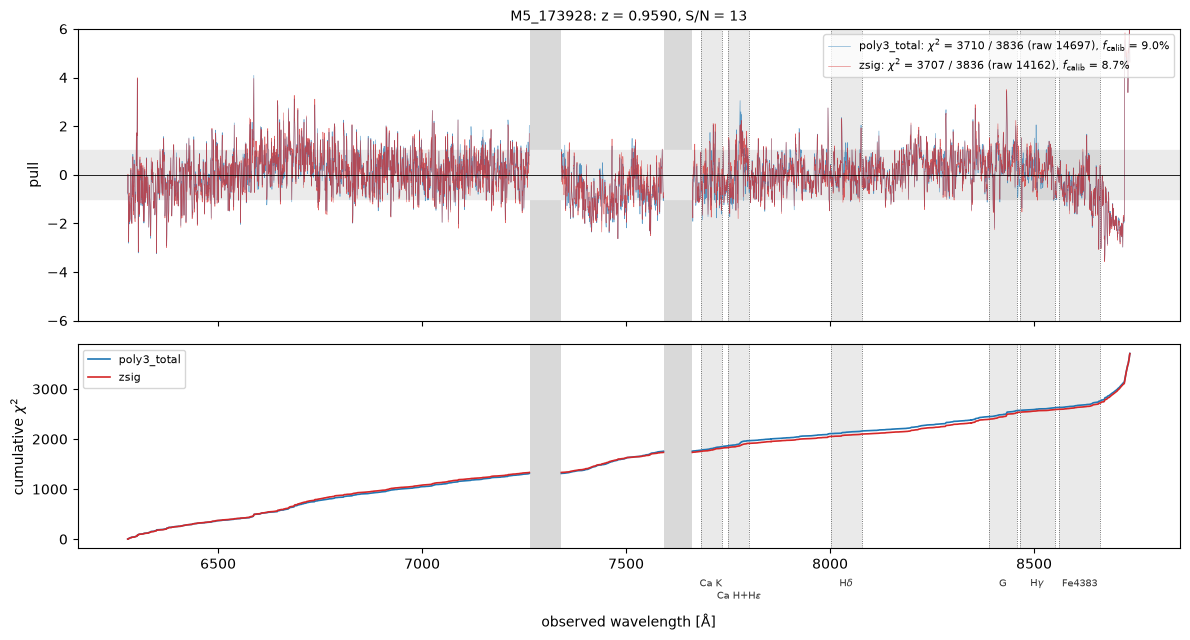

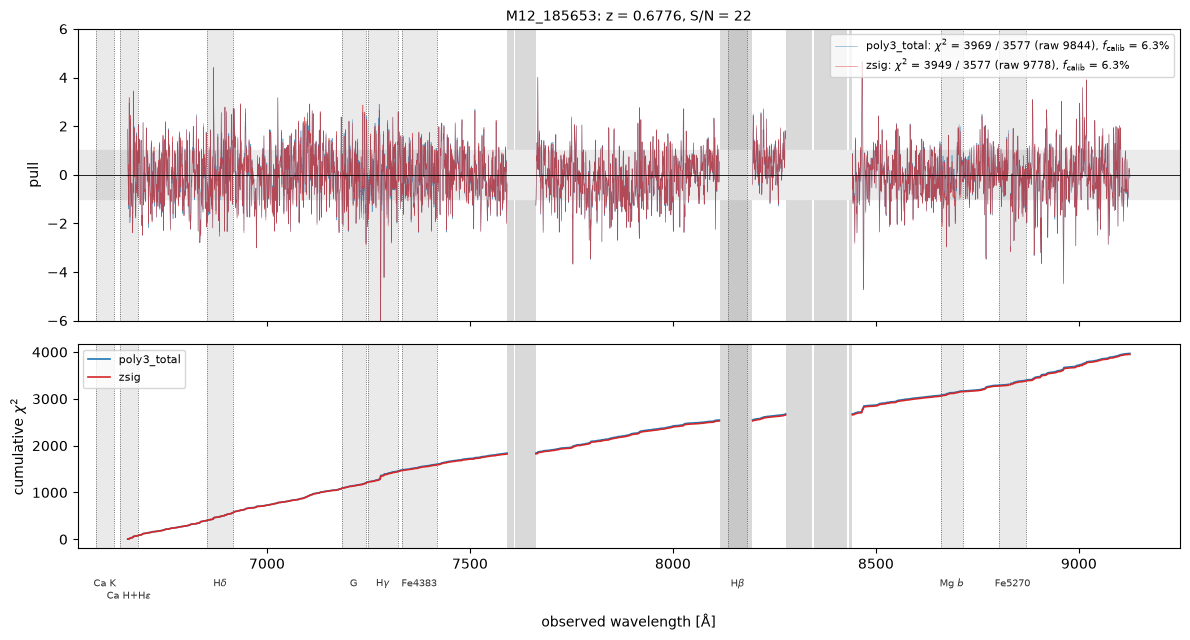

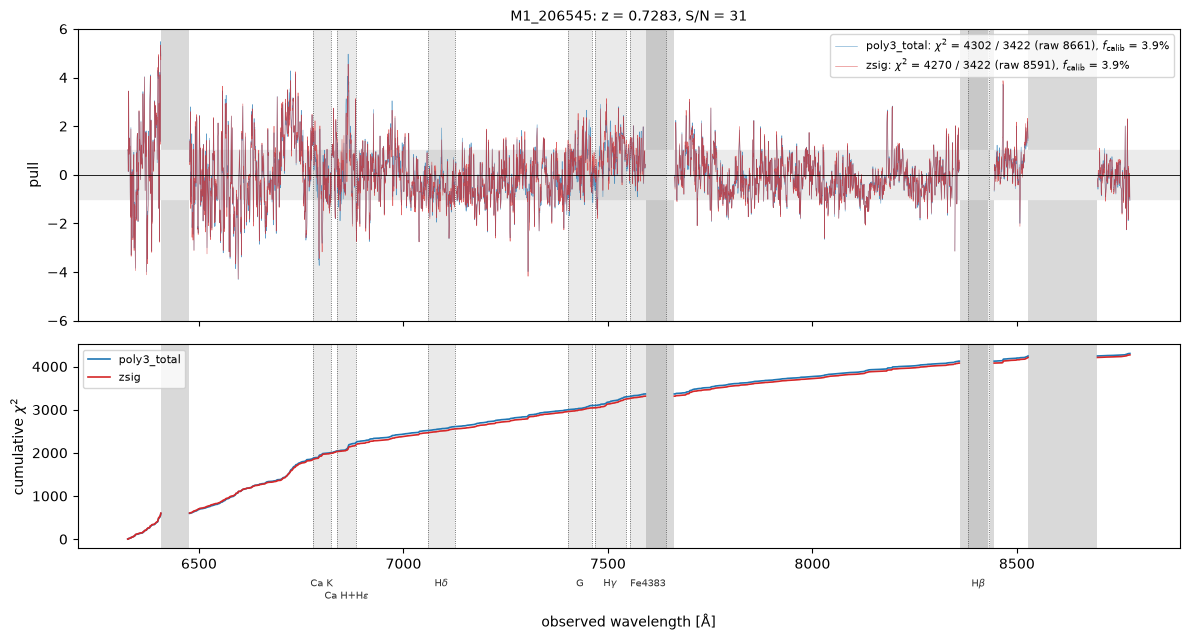

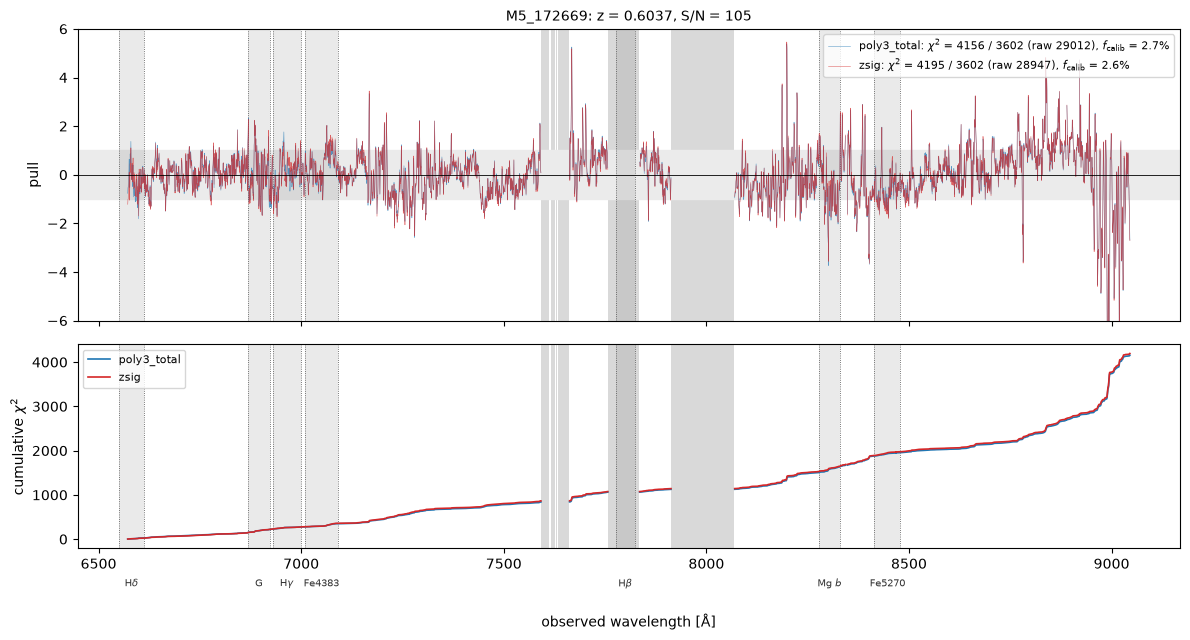

In [6]:
def _runs(wave, flag):
    edges = np.flatnonzero(np.diff(np.concatenate([[0], flag.astype(int), [0]])))
    return [(wave[a], wave[min(b, len(wave)) - 1]) for a, b in zip(edges[::2], edges[1::2])]


for target in galaxies:
    arms_here = [a for a in ARMS if (a, target) in fits]
    fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True, gridspec_kw={"height_ratios": [2, 1.4]})
    ref = fits[(arms_here[0], target)]["spectrum"]
    wave = ref["wavelength"]
    excluded = (ref["uncertainty"] < 1.0) & ~ref["mask"].astype(bool)
    for ax in axes:
        for lo, hi in _runs(wave, excluded):
            ax.axvspan(lo, hi, color="0.85", lw=0, zorder=0)
    for arm in arms_here:
        spec = fits[(arm, target)]["spectrum"]
        mask = spec["mask"].astype(bool)
        pull = np.where(mask, spec["pull"], np.nan)
        cumulative = np.where(mask, np.cumsum(np.where(mask, spec["pull"] ** 2, 0.0)), np.nan)
        row = table.loc[(target, arm)]
        axes[0].plot(wave, pull, lw=0.4, color=COLOURS[arm], alpha=0.7,
                     label=f"{arm}: $\\chi^2$ = {row['spec_chi2_stored']:.0f} / {row['n_pix']} "
                           f"(raw {row['spec_chi2_raw']:.0f}), $f_{{\\rm calib}}$ = {row['f_calib_q50']:.1f}%")
        axes[1].plot(wave, cumulative, lw=1.2, color=COLOURS[arm], label=arm)
    axes[0].axhspan(-1, 1, color="0.92", zorder=0)
    axes[0].axhline(0, color="k", lw=0.6)
    axes[0].set_ylim(-6, 6)
    axes[0].set_ylabel("pull")
    axes[0].legend(fontsize=8, loc="upper right")
    axes[0].set_title(f"{target}: z = {row['z']:.4f}, S/N = {row['sn']:.0f}", fontsize=10)
    axes[1].set_ylabel(r"cumulative $\chi^2$")
    mark_absorption_features(axes[0], row["z"], show_labels=False)
    mark_absorption_features(axes[1], row["z"],
                             xlabel=r"observed wavelength [$\mathrm{\AA}$]")
    axes[1].legend(fontsize=8, loc="upper left")
    fig.tight_layout()
    fig.savefig(RESULTS / f"chi2-{target}.png", dpi=130)
    plt.show()

## Derived parameters, fixed against free

- Point: median; bar: 16-84 range.

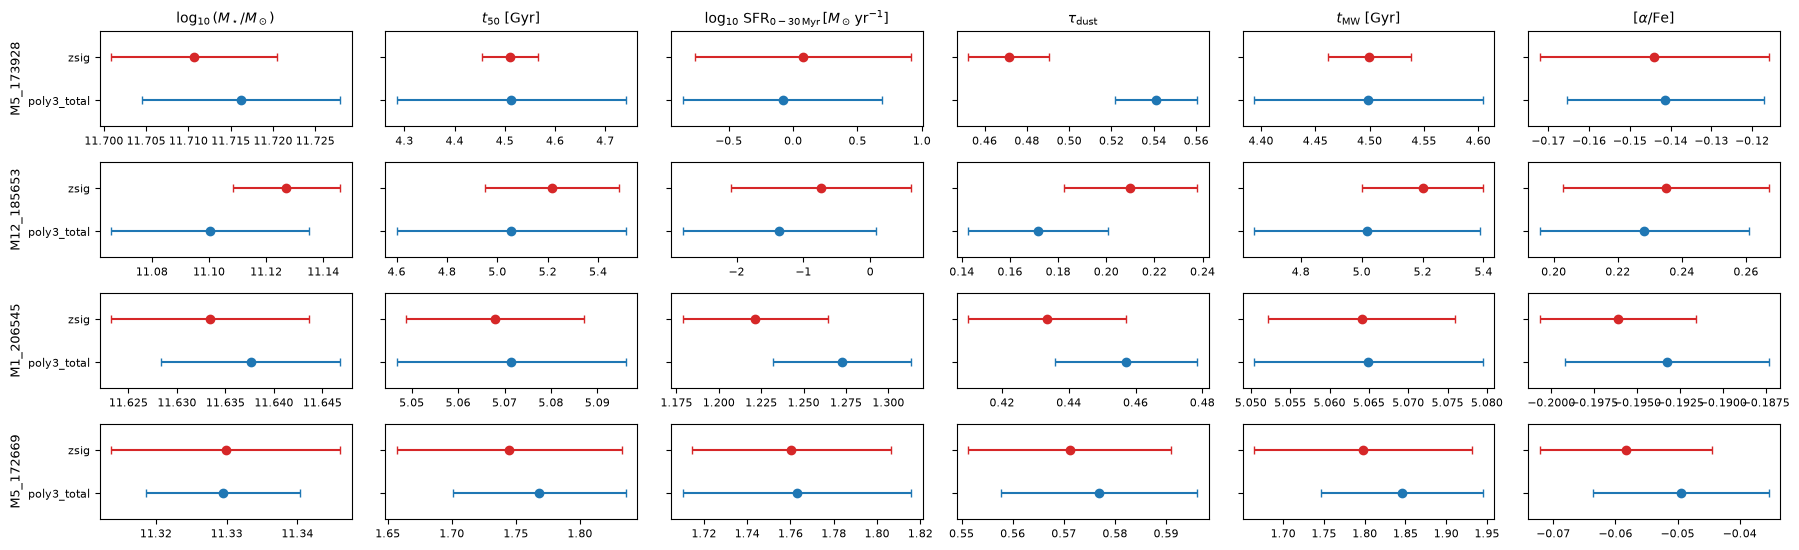

In [7]:
params = ["logmass", "t50", "log_sfr", "tau_dust", "age", "afe"]
fig, axes = plt.subplots(len(galaxies), len(params), figsize=(3.0 * len(params), 1.4 * len(galaxies)), squeeze=False)
for r, target in enumerate(galaxies):
    for c, name in enumerate(params):
        ax = axes[r, c]
        for i, arm in enumerate(ARMS):
            if (target, arm) not in table.index:
                continue
            row = table.loc[(target, arm)]
            ax.errorbar(row[f"{name}_q50"], i, xerr=row[f"{name}_hw"], fmt="o", color=COLOURS[arm], capsize=3)
        ax.set_yticks(range(len(ARMS)))
        ax.set_yticklabels(ARMS if c == 0 else [""] * len(ARMS), fontsize=8)
        ax.set_ylim(-0.6, len(ARMS) - 0.4)
        ax.tick_params(axis="x", labelsize=8)
        if r == 0:
            ax.set_title(LABELS[name], fontsize=10)
        if c == 0:
            ax.set_ylabel(target, fontsize=9)
fig.tight_layout()
fig.savefig(RESULTS / "parameters-fixed-vs-free.png", dpi=130)
plt.show()

## Star-formation histories

- Mass formed more recently than each lookback time, median and 16-84 band, both arms.

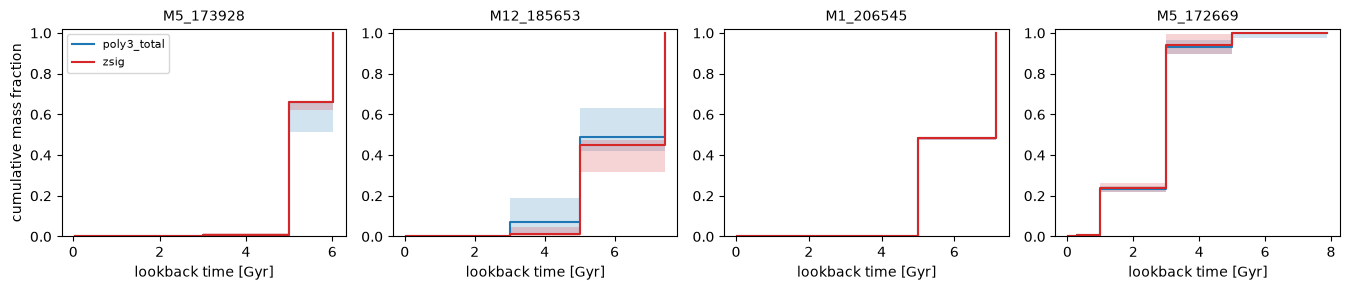

In [8]:
fig, axes = plt.subplots(1, len(galaxies), figsize=(3.4 * len(galaxies), 3.0), squeeze=False)
for ax, target in zip(axes[0], galaxies):
    for arm in ARMS:
        if (arm, target) not in fits:
            continue
        sfh = fits[(arm, target)]["sfh"]
        edges = sfh["lookback_time_gyr"]                       # bin edges, young to old
        cumulative = np.cumsum(sfh["mass_fraction_draws"], axis=1)   # mass formed since each edge
        q16, q50, q84 = np.percentile(cumulative, [16, 50, 84], axis=0)
        ax.plot(edges[1:], q50, drawstyle="steps-post", color=COLOURS[arm], label=arm)
        ax.fill_between(edges[1:], q16, q84, step="post", color=COLOURS[arm], alpha=0.2, lw=0)
    ax.set_title(target, fontsize=10)
    ax.set_xlabel("lookback time [Gyr]")
    ax.set_ylim(0, 1.02)
axes[0, 0].set_ylabel("cumulative mass fraction")
axes[0, 0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS / "sfh-fixed-vs-free.png", dpi=130)
plt.show()